# 2025-02-25 16S example assessment


## Summary

We are going to run a few samples through PacBio and Illumina RNA16S sequencing to improve the coverage of our experiment. To be certain about what are the capabilities of these two technologies, we should choose our examples wisely. We decided that we would send two very promising samples where we should see a lot of signal; additionally, we could send two samples where the signal that we expect is low. These two groups would provide us with higher and lower bounds for our effort.

Additionally, there are on-going experiments and articles trying to confirm the ultra-sequencing results by qPCR. We wish that our data coincides with those experiments, as it would enable us to write a more solid paper. 

## Loading data

In [53]:
import pandas as pd
import seaborn as sns 

We have the following sources of data:
- **Bacteria RNA Counts.** This ones are provided by the previous work done by Marco.
- **Samples characterized with qPCR for PZSV**
- **Samples characterized with qPCR for CMV**
Additionally, we have another dataset of libraries that have been analyzed again by qPCR. However, such a library has an unclear format.

In [89]:
marco_counts = pd.read_csv('../data/Marco-count-table.csv', sep='\t')
marco_counts

,OTU,lib,taxon,site,habitat,count
0,Aurantimonas endophytica,PV001,Amaranthus_sp,M1,crop,6
1,Candidatus Burkholderia kirkii UZHbot1,PV001,Amaranthus_sp,M1,crop,16
2,Cupriavidus gilardii,PV001,Amaranthus_sp,M1,crop,110
3,Duganella sp. Leaf126,PV001,Amaranthus_sp,M1,crop,2758
4,Dyadobacter endophyticus,PV001,Amaranthus_sp,M1,crop,1162
...,...,...,...,...,...,...
11228,Sphingopyxis granuli,PV055,Thymus_vulgaris,Q4,oak,6
11229,Streptomyces avicenniae,PV055,Thymus_vulgaris,Q4,oak,2
11230,Tenacibaculum agarivorans,PV055,Thymus_vulgaris,Q4,oak,2
11231,Tenacibaculum soleae,PV055,Thymus_vulgaris,Q4,oak,2


In [140]:
print('\n'.join(marco_counts['lib'].sort_values().unique().tolist()))

PV001
PV002
PV003
PV003bgi
PV004bgi
PV005bgi
PV006bgi
PV007bgi
PV008bgi
PV009
PV009bgi
PV010bgi
PV011
PV012bgi
PV013bgi
PV014
PV015bgi
PV016
PV017bgi
PV018bgi
PV020bgi
PV021bgi
PV022
PV023
PV024
PV025
PV026
PV027
PV028
PV029
PV030
PV031
PV032
PV033
PV034
PV035
PV036
PV037
PV041
PV042
PV046
PV047
PV048
PV049
PV050
PV051
PV052
PV053
PV054
PV055
PV056
PV057
PV058
PV059
PV060
PV061
PV062
PV063
PV064
PV065
PV066
PV067
PV068
PV069
PV070
PV071
PV072
PV074
PV075
PV076
PV078
PV079
PV080
PV081
PV082
PV083
PV084
PV085
PV086
PV087
PV088
PV089
PV090
PV091
PV092
PV093
PV094
PV095
PV096
PV097
PV098
PV099
PV100
PV101
PV102
PV103
PV104
PV105
PV106
PV107
PV108
PV109
PV110
PV111
PV112
PV113
PV114
PV115
PV116
PV117
PV118
PV119
PV120
PV121
PV122
PV123
PV124
PV125
PV126
PV127
PV128
PV129
PV130
PV131
PV132
PV133
PV134
PV135
PV136
PV137
PV138
PV139
PV140
PV141
PV142
PV143
PV144
PV145
PV146
PV147
PV148
PV149
PV150
PV151
PV152
PV153
PV154
PV155
PV156
PV157
PV158
PV159
PV160
PV161
PV162
PV163
PV164
PV165
PV166
P

<Axes: xlabel='habitat'>

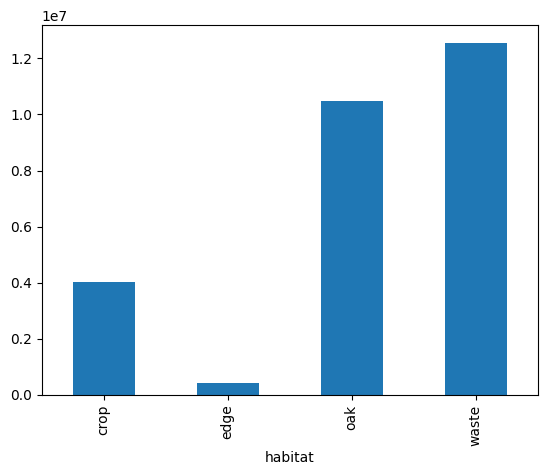

In [90]:
marco_counts.groupby('habitat')['count'].sum().plot(kind='bar')

The CSV and PZSV qPCR data is loaded from similar CSV files

In [94]:
CMV_resampling_df = pd.read_csv(
    "../data/2025-02-25-qPCR-Resampling-BB-CMV.csv", 
    sep='\t'
).query('Resampled == True')[['lib', 'habitat']]
CMV_resampling_df

,lib,habitat
0,PV495,Crop
10,PV015bgi,Crop
11,PV016,Crop
12,PV514,Crop
16,PV063,Crop
20,PV047,Crop
24,PV199,Edge
36,PV128,Edge
44,PV123,Edge
62,PV131,Edge


In [95]:
PZSV_resampling_df = pd.read_csv(
    "../data/2025-02-25-qPCR-Resampling-BB-PZSV.csv", 
    sep='\t'
).query('Resampled == True')[['lib', 'habitat']]
PZSV_resampling_df

,lib,habitat
0,PV557,Crop
2,PV501,Crop
3,PV514,Crop
9,PV208,Edge
12,PV207,Edge
13,PV205,Edge
14,PV201,Edge
19,PV204,Edge
27,PV116,Edge
29,PV121,Edge


In [97]:
CMV_merge_df = pd.merge(marco_counts, CMV_resampling_df[['lib']], on=['lib'], how='inner')
PZSV_merge_df = pd.merge(marco_counts, PZSV_resampling_df[['lib']], on=['lib'], how='inner')
CMV_merge_df

,OTU,lib,taxon,site,habitat,count
0,Cupriavidus gilardii,PV015bgi,Cucumis_melo,M2,crop,8
1,Delftia acidovorans SPH-1,PV015bgi,Cucumis_melo,M2,crop,12
2,Duganella sp. Leaf126,PV015bgi,Cucumis_melo,M2,crop,520
3,Dyadobacter endophyticus,PV015bgi,Cucumis_melo,M2,crop,590
4,Ensifer shofinae,PV015bgi,Cucumis_melo,M2,crop,682
...,...,...,...,...,...,...
1554,Sphingomonas phyllosphaerae FA2,PV054,Thymus_vulgaris,Q4,oak,4
1555,Sphingomonas sanguinis NBRC 13937,PV054,Thymus_vulgaris,Q4,oak,2
1556,Tamlana nanhaiensis,PV054,Thymus_vulgaris,Q4,oak,6
1557,Tardiphaga robiniae,PV054,Thymus_vulgaris,Q4,oak,2


## By total counts

In [ ]:
CMV_merge_df_bycounts = CMV_merge_df.groupby(['lib', 'habitat'], as_index=False)['count'].sum().sort_values(ascending=False, by='count')
PZSV_merge_df_bycounts = PZSV_merge_df.groupby(['lib', 'habitat'], as_index=False)['count'].sum().sort_values(ascending=False, by='count')

In [110]:
color_palette = sns.color_palette('Set1', 4)
palette = {'oak': color_palette[0], 'waste': color_palette[1], 'crop': color_palette[2], 'edge': color_palette[3]}

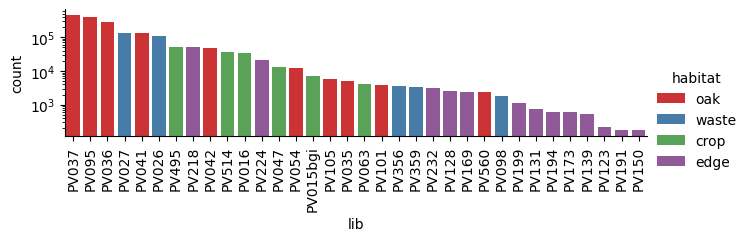

In [116]:
g = sns.catplot(x='lib', y='count', kind='bar', data=CMV_merge_df_bycounts, aspect=3.5, height=2.0, hue='habitat', palette=palette)
g.axes[0, 0].set_yscale('log')
g.set_xticklabels(rotation=90)

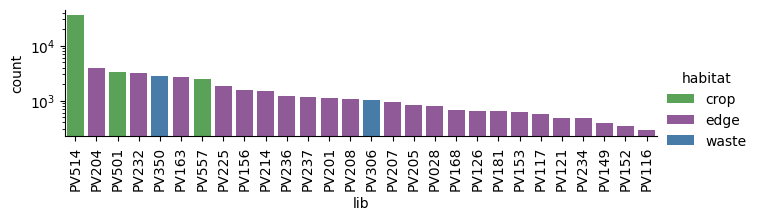

In [117]:
g = sns.catplot(x='lib', y='count', kind='bar', data=PZSV_merge_df_bycounts, aspect=3.5, height=2.0, hue='habitat', palette=palette)
g.axes[0, 0].set_yscale('log')
g.set_xticklabels(rotation=90)

## By diversity

In [104]:
CMV_merge_df_byotus = CMV_merge_df.groupby(['lib', 'habitat'], as_index=False)['OTU'].count().sort_values(ascending=False, by='OTU')
PZSV_merge_df_byotus = PZSV_merge_df.groupby(['lib', 'habitat'], as_index=False)['OTU'].count().sort_values(ascending=False, by='OTU')

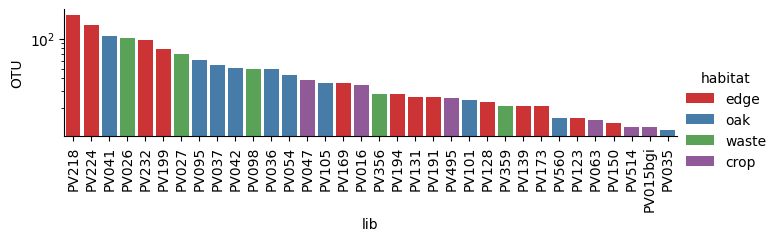

In [130]:
g = sns.catplot(x='lib', y='OTU', kind='bar', data=CMV_merge_df_byotus, aspect=3.5, height=2.0, hue='habitat', palette=color_palette)
g.axes[0, 0].set_yscale('log')
g.set_xticklabels(rotation=90)

/var/folders/xl/z7y434d524s8xpvqnb0gst580000gn/T/ipykernel_32735/1278155413.py:1: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  g = sns.catplot(x='lib', y='OTU', kind='bar', data=PZSV_merge_df_byotus, aspect=3.5, height=2.0, hue='habitat', palette=color_palette)


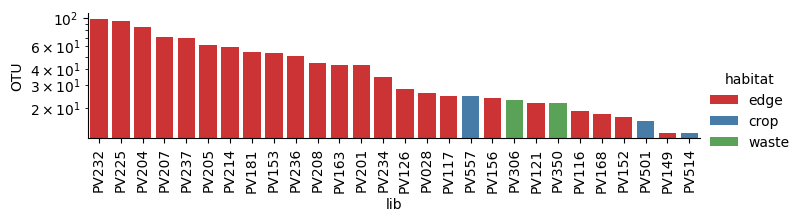

In [131]:
g = sns.catplot(x='lib', y='OTU', kind='bar', data=PZSV_merge_df_byotus, aspect=3.5, height=2.0, hue='habitat', palette=color_palette)
g.axes[0, 0].set_yscale('log')
g.set_xticklabels(rotation=90)

## Comparing results among viral-qPCR

In [119]:
CMV_merge_df_byotus_bycounts = pd.merge(CMV_merge_df_byotus, CMV_merge_df_bycounts, on=['lib', 'habitat'])
CMV_merge_df_byotus_bycounts[:10]

,lib,habitat,OTU,count
0,PV218,edge,174,50292
1,PV224,edge,138,21000
2,PV041,oak,107,131660
3,PV026,waste,101,111260
4,PV232,edge,98,3194
5,PV199,edge,78,1124
6,PV027,waste,70,135916
7,PV095,oak,61,397434
8,PV037,oak,54,457812
9,PV042,oak,51,46954


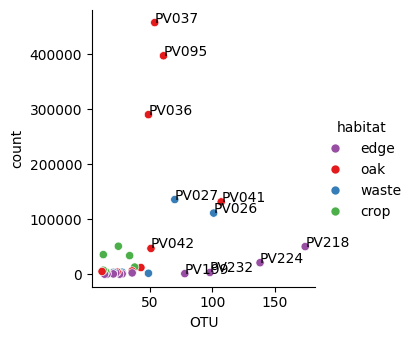

In [120]:
g = sns.relplot(data=CMV_merge_df_byotus_bycounts, x='OTU', y='count', hue='habitat', height=3.5, palette=palette)
for i, row in CMV_merge_df_byotus_bycounts.query('count > 100000 or OTU > 50').iterrows():
    g.axes[0, 0].text(row['OTU'], row['count'], row.lib)

In [121]:
PZSV_merge_df_byotus_bycounts = pd.merge(PZSV_merge_df_byotus, PZSV_merge_df_bycounts, on=['lib', 'habitat'])
PZSV_merge_df_byotus_bycounts[:10]

,lib,habitat,OTU,count
0,PV232,edge,98,3194
1,PV225,edge,94,1862
2,PV204,edge,85,3884
3,PV207,edge,71,936
4,PV237,edge,69,1178
5,PV205,edge,61,844
6,PV214,edge,59,1492
7,PV181,edge,54,648
8,PV153,edge,53,614
9,PV236,edge,51,1216


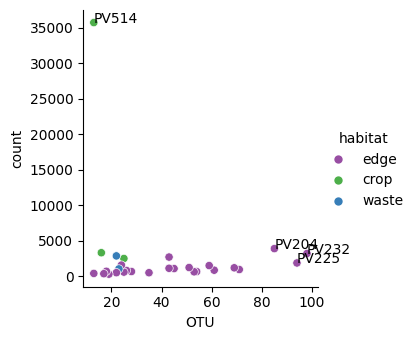

In [127]:
g = sns.relplot(data=PZSV_merge_df_byotus_bycounts, x='OTU', y='count', hue='habitat', height=3.5, palette=palette)
for i, row in PZSV_merge_df_byotus_bycounts.query('count > 10000 or OTU > 80').iterrows():
    g.axes[0, 0].text(row['OTU'], row['count'], row.lib)